In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from nn.preprocess import one_hot_encode_seqs, sample_seqs
from nn.io import read_text_file, read_fasta_file
from nn.nn import NeuralNetwork
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Digits

### Load data and split to test-train

In [2]:
digits = load_digits()
X = digits.data
y = digits.target
#do 80-20 test split 
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class distribution balanced
)
X_train = X_train.T
X_val = X_val.T
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

Training set shape: (64, 1437)
Validation set shape: (64, 360)


In [3]:
# Normalize to [0,1] (digits data has values 0-16)
eps = 1e-8
train_max = X_train.max()
if train_max <= 0:
    print("Warning: training data max <= 0, skipping scaling.")
else:
    X_train = X_train / (train_max + eps)
    X_val = X_val / (train_max + eps)

print("Processed shapes (features, examples):", X_train.shape, X_val.shape)

Processed shapes (features, examples): (64, 1437) (64, 360)


### Generate an instance of your NeuralNetwork class with a 64x16x64 autoencoder architecture.


In [4]:
nn_arch = [
    {"input_dim": 64, "output_dim": 16, "activation": "relu"},   # encoder
    {"input_dim": 16, "output_dim": 64, "activation": "linear"}  # decoder / reconstruction
]
model = NeuralNetwork(
    nn_arch=nn_arch,
    lr=1e-3,
    seed=42,
    batch_size=32,
    epochs=50,
    loss_function="mean_squared_error"
)

### Train the model

In [5]:
history = model.fit(X_train, X_train, X_val, X_val)

Epoch 1/50  train_loss=0.086593  val_loss=0.087138
Epoch 2/50  train_loss=0.065670  val_loss=0.066149
Epoch 3/50  train_loss=0.057004  val_loss=0.057620
Epoch 4/50  train_loss=0.048639  val_loss=0.049309
Epoch 5/50  train_loss=0.042180  val_loss=0.042810
Epoch 6/50  train_loss=0.037920  val_loss=0.038564
Epoch 7/50  train_loss=0.034607  val_loss=0.035191
Epoch 8/50  train_loss=0.032095  val_loss=0.032778
Epoch 9/50  train_loss=0.030118  val_loss=0.030892
Epoch 10/50  train_loss=0.028457  val_loss=0.029177
Epoch 11/50  train_loss=0.027008  val_loss=0.027791
Epoch 12/50  train_loss=0.025659  val_loss=0.026270
Epoch 13/50  train_loss=0.024401  val_loss=0.025023
Epoch 14/50  train_loss=0.023216  val_loss=0.023779
Epoch 15/50  train_loss=0.022172  val_loss=0.022684
Epoch 16/50  train_loss=0.021210  val_loss=0.021667
Epoch 17/50  train_loss=0.020355  val_loss=0.020880
Epoch 18/50  train_loss=0.019600  val_loss=0.020123
Epoch 19/50  train_loss=0.018914  val_loss=0.019380
Epoch 20/50  train_lo

### Plot loss

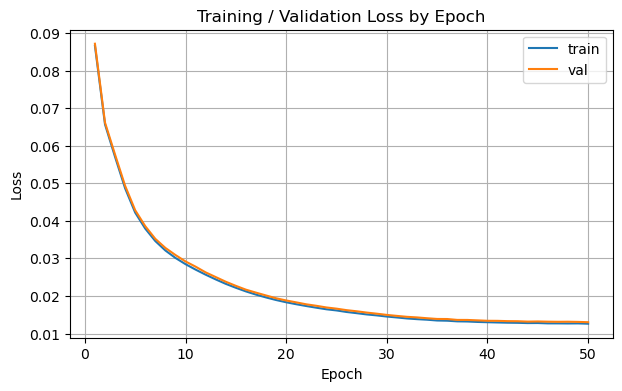

In [6]:
hist_dict = history
train_loss = hist_dict.get("train_loss")
val_loss = hist_dict.get("val_loss")
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs, train_loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss by Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Quantify your average reconstruction error over the validation set.

In [7]:
# Get reconstructions
A_val = model.forward(X_val)
# print(A_val)
per_example_mse = np.mean((X_val - A_val) ** 2, axis=0) #mean over 64 pixels for each image

avg_mse = per_example_mse.mean()
std_mse = per_example_mse.std()
# avg_rmse = np.sqrt(avg_mse)

print("Validation Reconstruction Error:")
print(f"Average MSE  : {avg_mse:.6f}")
print(f"Std of MSE   : {std_mse:.6f}")
# print(f"Average RMSE : {avg_rmse:.6f}")

Validation Reconstruction Error:
Average MSE  : 0.013011
Std of MSE   : 0.005312


### Parameters choice explanation
1. MSE as error because pixel values are continuous so it's more appropriate than BCE.
2. `1e-3` learning rate because that seems to be just be a standard.
3. Batch size of 32 which is a standard mini-batch size
4. Epoch=50 because I see no further improvement after

# DNA TF

### Read input files

In [8]:
# Read input files
positives = read_text_file('data/rap1-lieb-positives.txt')
negatives = read_fasta_file('data/yeast-upstream-1k-negative.fa')
print(f'Number of sequences in RAP1 positive = {len(positives)}')
print(f'Number of sequences in yeast negative = {len(negatives)}')

Number of sequences in RAP1 positive = 137
Number of sequences in yeast negative = 3163


### Balance classes

In [9]:
# Balance classes with `sample_seq` function
seqs = positives + negatives
labels = [True] * len(positives) + [False] * len(negatives)
sampled_seqs, sampled_labels = sample_seqs(seqs,labels)
print(len(sampled_seqs), len(sampled_labels))

6326 6326


### Pad Positive samples with Ns

In [10]:
padded_sampled_seqs = []
for i in sampled_seqs:
    if len(i) != 1000:  # for all sequences
        padded_seqs = i + "N" * (1000 - len(i))
    else:
        padded_seqs = i
    padded_sampled_seqs.append(padded_seqs)

### One-hot encode the data

In [11]:
N_expected = len(padded_sampled_seqs)
L_expected = len(padded_sampled_seqs[0])  # e.g., 1000
C_expected = 4  # one-hot channels (A,C,G,T)
expected_total = N_expected * L_expected * C_expected

# call the function (you probably already called it — re-call or reuse variable)
onehot_flat = one_hot_encode_seqs(padded_sampled_seqs)  # returns 1-D flattened array per your note

# convert to numpy array
arr = np.asarray(onehot_flat)
print("one_hot_encode_seqs returned ndarray with shape:", arr.shape, "dtype:", arr.dtype)

# reshape onehot encoded array
X = arr.reshape(N_expected, L_expected * C_expected).astype(np.float32)
print(f"Reshaped flat array to X with shape {X.shape} (N, L*C).")

# # If it's 1-D and length matches expected, reshape to (N, L*C)
# if arr.ndim == 1:
#     if arr.size != expected_total:
#         raise ValueError(
#             f"Flattened one-hot length {arr.size} does not match expected N*L*C ({expected_total}).\n"
#             f"Check N={N_expected}, L={L_expected}, C={C_expected}."
#         )
#     X = arr.reshape(N_expected, L_expected * C_expected).astype(np.float32)
#     print(f"Reshaped flat array to X with shape {X.shape} (N, L*C).")
# else:
#     # fallback: if not 1-D, try previously used heuristics (keeps notebook robust)
#     if arr.ndim == 3 and arr.shape[0] == N_expected:
#         # (N, L, C)
#         X = arr.reshape(N_expected, L_expected * C_expected).astype(np.float32)
#         print("Detected (N, L, C) -> flattened to (N, L*C).")
#     elif arr.ndim == 2 and arr.shape[0] == N_expected:
#         X = arr.astype(np.float32)
#         print("Detected (N, L*C) already.")
#     elif arr.ndim == 2 and arr.shape[1] == N_expected and arr.shape[0] == L_expected * C_expected:
#         X = arr.T.astype(np.float32)
#         print("Detected transposed (L*C, N) -> transposed to (N, L*C).")
#     else:
#         raise ValueError(
#             f"one_hot_encode_seqs returned an ndarray with unexpected shape {arr.shape}. "
#             "Expected flattened 1-D of length N*L*C, or (N,L,C), or (N, L*C)."
#         )

one_hot_encode_seqs returned ndarray with shape: (25304000,) dtype: int64
Reshaped flat array to X with shape (6326, 4000) (N, L*C).


### Split data into training-testing

In [12]:
# Prepare labels
y = np.array(sampled_labels).astype(np.int64).reshape(-1, 1)
print("Labels shape:", y.shape)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)# Stratified train/validation split
print("Train shapes:", X_train.shape, y_train.shape)
print("Val shapes:  ", X_val.shape, y_val.shape)

Labels shape: (6326, 1)
Train shapes: (5060, 4000) (5060, 1)
Val shapes:   (1266, 4000) (1266, 1)


### Train the model

In [13]:
# Hyperparameters
input_dim = X_train.shape[1]
nn_arch = [
    {"input_dim": input_dim, "output_dim": 64, "activation": "relu"},
    {"input_dim": 64, "output_dim": 32, "activation": "relu"},
    {"input_dim": 32, "output_dim": 1, "activation": "sigmoid"}]

# Instantiate the model
model = NeuralNetwork(
    nn_arch=nn_arch,
    lr=1e-3,
    seed=42,
    batch_size=32,
    epochs=20,
    loss_function="binary_cross_entropy")

#transpose
X_train_T = X_train.T
X_val_T   = X_val.T
y_train_T = y_train.reshape(-1, 1).T
y_val_T   = y_val.reshape(-1, 1).T

# fit the model
history = model.fit(X_train_T, y_train_T, X_val_T, y_val_T)
print("model.fit returned type:", type(history))

#get thistory
normalized_history = {}
if "loss" in history:
    normalized_history["train_loss"] = history["loss"]
if "val_loss" in history:
    normalized_history["val_loss"] = history["val_loss"]
if "train_loss" in history:
    normalized_history["train_loss"] = history["train_loss"]
if "val_loss" in history:
    normalized_history["val_loss"] = history["val_loss"]
# fallback: pick any list-like value as train loss if nothing obvious
if not normalized_history and history:
    for k, v in history.items():
        if isinstance(v, (list, tuple, np.ndarray)):
            normalized_history["train_loss"] = v
            break

normalized_history.setdefault("train_loss", [])
normalized_history.setdefault("val_loss", [])
history = normalized_history

print("Collected history keys:", list(history.keys()))
print("Train-loss entries:", len(history["train_loss"]))

Epoch 1/20  train_loss=0.001531  val_loss=0.001788
Epoch 2/20  train_loss=0.000420  val_loss=0.000562
Epoch 3/20  train_loss=0.000225  val_loss=0.000336
Epoch 4/20  train_loss=0.000131  val_loss=0.000200
Epoch 5/20  train_loss=0.000089  val_loss=0.000139
Epoch 6/20  train_loss=0.000058  val_loss=0.000090
Epoch 7/20  train_loss=0.000041  val_loss=0.000064
Epoch 8/20  train_loss=0.000031  val_loss=0.000048
Epoch 9/20  train_loss=0.000023  val_loss=0.000035
Epoch 10/20  train_loss=0.000018  val_loss=0.000027
Epoch 11/20  train_loss=0.000014  val_loss=0.000021
Epoch 12/20  train_loss=0.000011  val_loss=0.000017
Epoch 13/20  train_loss=0.000009  val_loss=0.000014
Epoch 14/20  train_loss=0.000007  val_loss=0.000011
Epoch 15/20  train_loss=0.000006  val_loss=0.000009
Epoch 16/20  train_loss=0.000005  val_loss=0.000008
Epoch 17/20  train_loss=0.000004  val_loss=0.000007
Epoch 18/20  train_loss=0.000004  val_loss=0.000006
Epoch 19/20  train_loss=0.000003  val_loss=0.000005
Epoch 20/20  train_lo

### Plot loss

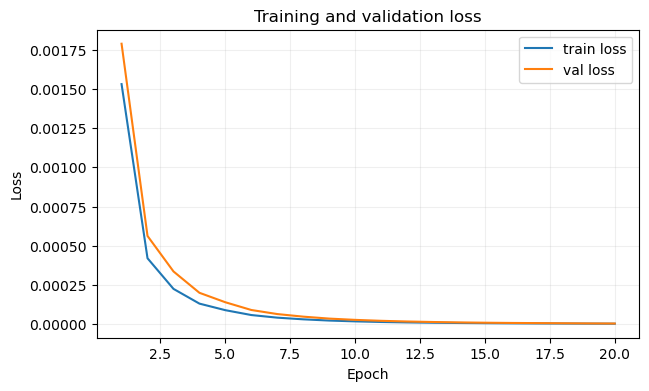

In [14]:
train_loss = history.get("train_loss", [])
val_loss = history.get("val_loss", [])
epochs_range = np.arange(1, len(train_loss) + 1)
plt.figure(figsize=(7,4))


plt.plot(epochs_range, train_loss, label="train loss")
if len(val_loss) > 0:
    # align lengths if mismatched
    if len(val_loss) == len(train_loss):
        plt.plot(epochs_range, val_loss, label="val loss")
    else:
        plt.plot(np.arange(1, len(val_loss)+1), val_loss, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Evaluation metrics

In [22]:
def model_predict_probs_column_major(model, X_np):
    """
    Accept X_np shape (n_samples, n_features) and return probs shape (n_samples,)
    by transposing for model, then converting model output back to (n_samples,).
    """
    X_T = X_np.T  # (features, n_samples)
    # try common predict method names
    if hasattr(model, "predict_proba"):
        out = model.predict_proba(X_T)
    elif hasattr(model, "predict"):
        out = model.predict(X_T)
    elif hasattr(model, "forward"):
        out = model.forward(X_T)
    else:
        raise RuntimeError("No predict/predict_proba/forward method on model.")
    p = np.asarray(out).reshape(-1)
    # If model returned shape (1, n) or (n,1), this reshape fixes it
    if p.size == X_np.shape[0]:
        return p
    # if output length mismatches, try transposing or flattening differently
    if p.size == X_np.shape[0]:
        return p
    return p[: X_np.shape[0]]

# get probabilities on validation set
probs_val = model_predict_probs_column_major(model, X_val)
# if logits, apply sigmoid
if probs_val.min() < 0 or probs_val.max() > 1:
    probs_val = 1 / (1 + np.exp(-probs_val))

preds_val = (probs_val >= 0.5).astype(int)
y_val_flat = y_val.reshape(-1)

acc = (preds_val == y_val_flat).mean()
cm = confusion_matrix(y_val_flat, preds_val)
prec = precision_score(y_val_flat, preds_val, zero_division=0)
rec = recall_score(y_val_flat, preds_val, zero_division=0)
f1 = f1_score(y_val_flat, preds_val, zero_division=0)
auc = roc_auc_score(y_val_flat, probs_val)

print(f"Validation accuracy: {acc*100:.2f}%")
print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)
print(f"\nPrecision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")
print(f"ROC AUC:   {auc:.3f}")

print("\nClassification report:")
print(classification_report(y_val_flat, preds_val, zero_division=0))

Validation accuracy: 100.00%

Confusion matrix (rows=true, cols=pred):
[[633   0]
 [  0 633]]

Precision: 1.000
Recall:    1.000
F1 score:  1.000
ROC AUC:   1.000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       633
           1       1.00      1.00      1.00       633

    accuracy                           1.00      1266
   macro avg       1.00      1.00      1.00      1266
weighted avg       1.00      1.00      1.00      1266



### Parameters choice explanation
1. BCE as error because we are performing a binary prediction (binding site or not)
2. `1e-3` learning rate because that seems to be just be a standard.
3. Batch size of 32 which is a standard mini-batch size
4. Epoch=20 is chosen because I didn't see further improvements afterwards